Link to dataset : https://drive.google.com/file/d/1sbQ5WJ-KCPBrhT2YagtaARGoujCMpB8Q/view


# SA-2025 WEEK 3 GRADED ASSIGNMENT

> Spaceship Titanic

Predict which passengers are transported to an alternate dimension

![](https://www.gannett-cdn.com/-mm-/682bf77435754aee88576469063388a7d8b07c2a/c=0-150-1280-873/local/-/media/2017/02/01/Reno/RGJ/636215634914521096-image001.jpg?width=660&height=373&fit=crop&format=pjpg&auto=webp)


### <b>Description</b>

Welcome to the year 2912, where your data science skills are needed to solve a cosmic mystery. We've received a transmission from four lightyears away and things aren't looking good.

The Spaceship Titanic was an interstellar passenger liner launched a month ago. With almost 13,000 passengers on board, the vessel set out on its maiden voyage transporting emigrants from our solar system to three newly habitable exoplanets orbiting nearby stars.

While rounding Alpha Centauri en route to its first destination—the torrid 55 Cancri E—the unwary Spaceship Titanic collided with a spacetime anomaly hidden within a dust cloud. Sadly, it met a similar fate as its namesake from 1000 years before. Though the ship stayed intact, almost half of the passengers were transported to an alternate dimension!


### <b>Data description</b>

- Personal records for about two-thirds (~8700) of the passengers, to be used as training data.
- <code>PassengerId</code> - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.
- <code>HomePlanet</code> - The planet the passenger departed from, typically their planet of permanent residence.
- <code>CryoSleep</code> - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.
- <code>Cabin</code> - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.
- <code>Destination</code> - The planet the passenger will be debarking to.
- <code>Age</code> - The age of the passenger.
- <code>VIP</code> - Whether the passenger has paid for special VIP service during the voyage.
- <code>RoomService, FoodCourt, ShoppingMall, Spa, VRDeck</code> - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.
- <code>Name</code> - The first and last names of the passenger.
- <code>Transported</code> - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.


### <b>Algorithm Documentation</b> (Highly recommended!)

- <code>Logistic Regression</code> : https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- <code>SVM</code> : https://scikit-learn.org/stable/modules/svm.html
  Confusion Matrix : https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
- <code>Plot Confusion Matrix</code> : https://scikit-learn.org/stable/modules/generated/sklearn.metrics.plot_confusion_matrix.html
- <code>ROC_AUC Score</code> : https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html#sklearn.metrics.roc_auc_score
- <code>Classification Report</code> : https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html
- <code>Label Encoder</code> : https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html
- <code>Label Binarizer</code> : https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelBinarizer.html
- <code>Standard Scaler</code> : https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
- <code>Cross Val Score</code> : https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html


# <span><h1 style = "font-family: garamond; font-size: 40px; font-style: normal; letter-spcaing: 3px; background-color: #f6f5f5; color :#fe346e; border-radius: 100px 100px; text-align:center">Install Required Libraries</h1></span>


In [62]:
%pip install --upgrade scikit-learn  
#There was an error with importing confusion_matrix from sklearn.mertices , so there was a need to upgrade it for google colab
# even after upgrading the plot_confusion_matrix didnt worked as it has been changed in new version

Note: you may need to restart the kernel to use updated packages.


In [63]:
## ======== YOUR CODE HERE ======== ##
from sklearn.metrics import confusion_matrix

#### Read the data


In [64]:
import pandas as pd

df = pd.read_csv("data.csv")

#### Check the shape of data. It should be (8693, 14)


In [65]:
## ======== YOUR CODE HERE ======== ##
df.shape
## ================================ ##

(8693, 14)

#### Apply describe on dataframe


In [66]:
## ======== YOUR CODE HERE ======== ##
df.describe(include="all")
#
## ================================ ##

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
count,8693,8693,8693,8693,8693,8693.000000,8693,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693,8693
unique,8693,3,2,6560,3,NaN,2,NaN,NaN,NaN,NaN,NaN,8473,2
top,0001_01,Earth,False,G/734/S,Andromeda,NaN,False,NaN,NaN,NaN,NaN,NaN,Alraium Disivering,True
freq,1,4803,5656,207,6097,NaN,8494,NaN,NaN,NaN,NaN,NaN,202,4378
mean,NaN,NaN,NaN,NaN,NaN,28.728517,NaN,220.009318,448.434027,169.572300,304.588865,298.261820,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,14.355438,NaN,660.519050,1595.790627,598.007164,1125.562559,1134.126417,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,20.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,37.000000,NaN,41.000000,61.000000,22.000000,53.000000,40.000000,NaN,NaN


#### Check if there any null value in the dataset.


In [67]:
## ======== YOUR CODE HERE ======== ##
df.isnull().sum()

## ================================ ##

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64

#### Number continuous and categorical features


In [68]:
#################################################################

# Don't make mistake here. Ask in the discussion section if you are stuck. Help will be provided....

#################################################################

## ======== YOUR CODE HERE ======== ##
continuous_cols = df.select_dtypes(include=["number"]).columns.value_counts().sum()
categorical_cols = (
    df.select_dtypes(include=["object", "category", "str"]).columns.value_counts().sum()
)


print("continuos features ", continuous_cols)
print("categorical fetaures ", categorical_cols)
## ======== YOUR CODE HERE ======== ##

continuos features  6
categorical fetaures  5


#### Unique values


In [69]:
# Print the number of unique values of the categorical features

## ======== YOUR CODE HERE ======== ##
print(df.nunique())

## ======== YOUR CODE HERE ======== ##

# seeing the n-unique for passengerID , we can say there is no error and no overlap in passengerID as all are unique .
# But there is an anomaly as Name of passengers might overlap as not all of them are unique .

PassengerId     8693
HomePlanet         3
CryoSleep          2
Cabin           6560
Destination        3
Age               80
VIP                2
RoomService     1273
FoodCourt       1507
ShoppingMall    1115
Spa             1327
VRDeck          1306
Name            8473
Transported        2
dtype: int64


<code>Note: If we apply one-hot-encoding to a categorical feature with many unique values, </code>

- Number of columns will be high
- Time required for training a model will be high
- We may not get usefull insights about the data

<code>This is the reason we are droping the features with more unique values.</code>


#### Drop the features


In [70]:
# Drop those categorical features which have more than 25 unique values
df.drop(
    columns=[
        col
        for col in df.select_dtypes(include=["object", "category", "str"]).columns
        if df[col].nunique() > 25
    ],
    inplace=True,
)

## ======== YOUR CODE HERE ======== ##

# Print the shape after droping the features
# Check: Shape --> (8693, 11)

## ======== YOUR CODE HERE ======== ##
df.shape
## ======== YOUR CODE HERE ======== ##

(8693, 11)

#### One Hot Encoding


In [71]:
# Hint: search for get_dummies

## ======== YOUR CODE HERE ======== ##

df = pd.get_dummies(df)
## ======== YOUR CODE HERE ======== ##
df.shape
# Check: Shape --> (8693, 15)

(8693, 15)

#### Changing bool columns to 0,1


In [72]:

df["CryoSleep"] = df["CryoSleep"].astype(int)
df["VIP"] = df["VIP"].astype(int)
df["Transported"] = df["Transported"].astype(int)

df.head()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_Andromeda,Destination_Cygnus,Destination_Virgo
0,0,39,0,0,0,0,0,0,0,False,True,False,True,False,False
1,0,24,0,109,9,25,549,44,1,True,False,False,True,False,False
2,0,58,1,43,3576,0,6715,49,0,False,True,False,True,False,False
3,0,33,0,0,1283,371,3329,193,0,False,True,False,True,False,False
4,0,16,0,303,70,151,565,2,1,True,False,False,True,False,False


#### Split the data into train and test


In [73]:
## ======== YOUR CODE HERE ======== ##

## Test size should be 15% of the full dataset and use random state = 2022
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.15, random_state=2022)

## ================================ ##

In [74]:
## ======== YOUR CODE HERE ======== ##

## Let us print the shapes:
print(df_train.shape, df_test.shape)
## ================================ ##

(7389, 15) (1304, 15)


#### Scale the data using Standard Scaler


In [75]:
## Use Standard Scaler to scale the train and test data


## ======== YOUR CODE HERE ======== ##
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit_transform(df_train)



## ================================ ##

array([[-0.73071355,  1.76909278, -0.15666024, ...,  0.65197571,
        -0.31370272, -0.51354161],
       [-0.73071355,  0.50762434, -0.15666024, ...,  0.65197571,
        -0.31370272, -0.51354161],
       [-0.73071355,  0.43754276, -0.15666024, ..., -1.53379948,
        -0.31370272,  1.94726187],
       ...,
       [-0.73071355, -0.26327304, -0.15666024, ..., -1.53379948,
         3.18773139, -0.51354161],
       [-0.73071355, -0.26327304, -0.15666024, ...,  0.65197571,
        -0.31370272, -0.51354161],
       [ 1.36852533, -0.0530283 , -0.15666024, ...,  0.65197571,
        -0.31370272, -0.51354161]], shape=(7389, 15))

## <b>Logistic Regression</b>

#### Use default parameters unless mentioned


In [93]:
## Use Random state = 2021 and fit the LR model

## ======== YOUR CODE HERE ======== ##
from sklearn.linear_model import LogisticRegression
df_train, df_test = train_test_split(df, test_size=0.15, random_state=2021)

lr = LogisticRegression(max_iter=200)


x_train = df_train.drop("Transported",axis=1)
y_train = df_train["Transported"]

x_train =scaler.fit_transform(x_train)
lr.fit( x_train , y_train)

## ================================ ##

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",200
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

#### Plot confusion matrix


In [94]:
## ======== YOUR CODE HERE ======== ##
x_test = df_test.drop("Transported",axis=1)
y_test = df_test["Transported"]
x_test =scaler.transform(x_test)

y_pred = lr.predict(x_test)
cf = confusion_matrix(y_true=y_test, y_pred=y_pred)
cf

## ================================ ##

array([[505, 168],
       [ 96, 535]])

#### Print classification report


In [95]:
## ======== YOUR CODE HERE ======== ##
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))
## ================================ ##

              precision    recall  f1-score   support

           0       0.84      0.75      0.79       673
           1       0.76      0.85      0.80       631

    accuracy                           0.80      1304
   macro avg       0.80      0.80      0.80      1304
weighted avg       0.80      0.80      0.80      1304



#### Print accuracy score


In [96]:
## ======== YOUR CODE HERE ======== ##

from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)
## ================================ ##

0.7975460122699386

#### Print ROC-AUC score


In [97]:
## ======== YOUR CODE HERE ======== ##

## Note: Use predict_proba!!! Read documentation/google it
from sklearn.metrics import roc_auc_score
y_prob_all = lr.predict_proba(x_test)
roc_auc_score(y_test,y_prob_all[ :,1])
# y_prob_all

## ================================ ##

0.8785366278672736

#### Plot ROC-AUC Curve


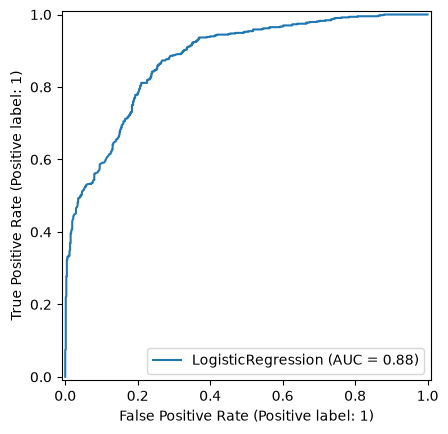

In [98]:
## ======== YOUR CODE HERE ======== ##

## Set appropriate X label, Y label and Title for the graph
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(lr,x_test,y_test)
plt.show()

## ================================ ##

#### Cross validation


In [99]:
## ======== YOUR CODE HERE ======== ##

## cv=5
from sklearn.model_selection import cross_validate
cross_validate(lr,x_train,y_train,cv=5)

## ================================ ##

{'fit_time': array([0.03178144, 0.0283494 , 0.01796579, 0.01900887, 0.02000165]),
 'score_time': array([0.00296807, 0.00699663, 0.00200677, 0.00199986, 0.00300026]),
 'test_score': array([0.78755074, 0.78010825, 0.79499323, 0.79972936, 0.76100203])}

## <b>SVM</b>

#### Use default parameters unless mentioned


In [113]:
## ======== YOUR CODE HERE ======== ##
from sklearn.svm import SVC
svm = SVC(probability=True)
svm.fit(x_train,y_train)
y_pred = svm.predict(x_test)

## ================================ ##

c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


#### Plot confusion matrix


In [114]:
## ======== YOUR CODE HERE ======== ##

## Use display labels as per your choice.
confusion_matrix(y_test,y_pred)

## ================================ ##

array([[516, 157],
       [117, 514]])

#### Print classification report


In [115]:
## ======== YOUR CODE HERE ======== ##
print(classification_report(y_test,y_pred))

## ================================ ##

              precision    recall  f1-score   support

           0       0.82      0.77      0.79       673
           1       0.77      0.81      0.79       631

    accuracy                           0.79      1304
   macro avg       0.79      0.79      0.79      1304
weighted avg       0.79      0.79      0.79      1304



#### Print accuracy score


In [116]:
## ======== YOUR CODE HERE ======== ##

accuracy_score(y_test,y_pred)
## ================================ ##

0.7898773006134969

#### Print ROC-AUC score


In [117]:
## ======== YOUR CODE HERE ======== ##

## Note: Use predict_proba!!! Read documentation/google it
y_prob_all = svm.predict_proba(x_test)
roc_auc_score(y_test,y_prob_all[ :,1])

## ================================ ##

0.8705090860282152

#### Plot ROC-AUC curve


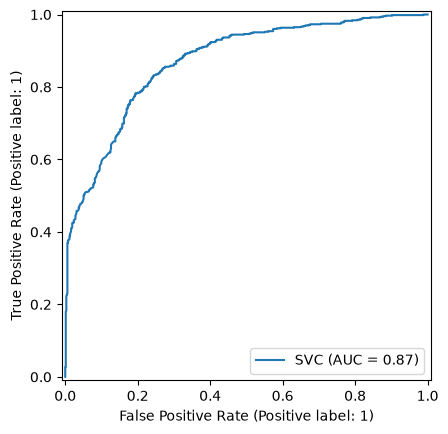

In [119]:
## ======== YOUR CODE HERE ======== ##

## Set appropriate X label, Y label and Title for the graph

RocCurveDisplay.from_estimator(svm,x_test,y_test)
plt.show()
## ================================ ##

#### Cross validation


In [120]:
## ======== YOUR CODE HERE ======== ##

## cv=5
cross_validate(svm,x_train,y_train,cv=5)

## ================================ ##

c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_bas

{'fit_time': array([ 7.81882715,  8.61214209, 17.47284222, 17.20808601, 16.60040045]),
 'score_time': array([0.5103209 , 1.51249361, 1.1650753 , 1.19360399, 1.13344717]),
 'test_score': array([0.79296346, 0.77875507, 0.78755074, 0.80311231, 0.76303318])}

# Congratulations! Assignment Completed!
